<a href="https://colab.research.google.com/github/Prateek-Dhar-Dwivedi/NLP_Practical_2026_Colab_Files/blob/main/Practical_1_NLP_CORPUSLENS_NLP_Corpus_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INSTALLING & IMPORT LIBRARIES



In [ ]:

!pip install nltk wordcloud pandas matplotlib seaborn -q

import nltk
import re
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

# Download required NLTK resources
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Import NLTK corpus and stopwords
from nltk.corpus import gutenberg
from nltk.corpus import stopwords

print("Libraries imported successfully!")
print("Available Gutenberg corpora:")
print(gutenberg.fileids())

Libraries imported successfully!
Available Gutenberg corpora:
['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



# LOADING A TEXT CORPUS

In [ ]:

# Selecting the document we want to analyze
document_name = 'carroll-alice.txt'

# Load raw text
raw_text = gutenberg.raw(document_name)

# Load tokenized words
words = gutenberg.words(document_name)

# Load tokenized sentences
sentences = gutenberg.sents(document_name)

print("Document loaded successfully!")
print("-" * 50)

print("Document:", document_name)
print("Total characters:", len(raw_text))
print("Total words/tokens:", len(words))
print("Total sentences:", len(sentences))

print("\nFirst 500 characters:")
print(raw_text[:500])

Document loaded successfully!
--------------------------------------------------
Document: carroll-alice.txt
Total characters: 144395
Total words/tokens: 34110
Total sentences: 1703

First 500 characters:
[Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversations in
it, 'and what is the use of a book,' thought Alice 'without pictures or
conversation?'

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy an


#CORPUS OVERVIEW

In [ ]:

# Keep only alphabetic words
clean_words = [
    word.lower()
    for word in words
    if word.isalpha()
]

# Calculate vocabulary
vocabulary = set(clean_words)

# Basic statistics
total_words = len(clean_words)
unique_words = len(vocabulary)
total_sentences = len(sentences)

# Average sentence length
average_sentence_length = total_words / total_sentences

# Average word length
average_word_length = sum(len(word) for word in clean_words) / total_words

# Lexical diversity
lexical_diversity = unique_words / total_words

print("=" * 55)
print("              CORPUS OVERVIEW")
print("=" * 55)

print(f"Total Characters       : {len(raw_text):,}")
print(f"Total Words            : {total_words:,}")
print(f"Unique Words           : {unique_words:,}")
print(f"Total Sentences        : {total_sentences:,}")
print(f"Average Sentence Length: {average_sentence_length:.2f} words")
print(f"Average Word Length    : {average_word_length:.2f} characters")
print(f"Lexical Diversity      : {lexical_diversity:.3f}")

              CORPUS OVERVIEW
Total Characters       : 144,395
Total Words            : 27,333
Unique Words           : 2,569
Total Sentences        : 1,703
Average Sentence Length: 16.05 words
Average Word Length    : 3.94 characters
Lexical Diversity      : 0.094


#CORPUS STATISTICS DASHBOARD

In [ ]:

statistics = {
    "Metric": [
        "Characters",
        "Words",
        "Unique Words",
        "Sentences",
        "Avg Sentence Length",
        "Avg Word Length",
        "Lexical Diversity"
    ],

    "Value": [
        len(raw_text),
        total_words,
        unique_words,
        total_sentences,
        round(average_sentence_length, 2),
        round(average_word_length, 2),
        round(lexical_diversity, 3)
    ]
}

stats_df = pd.DataFrame(statistics)

display(stats_df)

,Metric,Value
0,Characters,144395.000
1,Words,27333.000
2,Unique Words,2569.000
3,Sentences,1703.000
4,Avg Sentence Length,16.050
5,Avg Word Length,3.940
6,Lexical Diversity,0.094


#  WORD FREQUENCY ANALYSIS

In [ ]:
# Count every alphabetic word
word_frequency = Counter(clean_words)

# Get the 20 most common words
top_words = word_frequency.most_common(20)

# Convert results into a DataFrame
frequency_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

print("Top 20 Most Frequent Words:")
display(frequency_df)

Top 20 Most Frequent Words:


,Word,Frequency
0,the,1642
1,and,872
2,to,729
3,a,632
4,it,595
5,she,553
6,i,543
7,of,514
8,said,462
9,you,411


#  WORD FREQUENCY VISUALIZATION

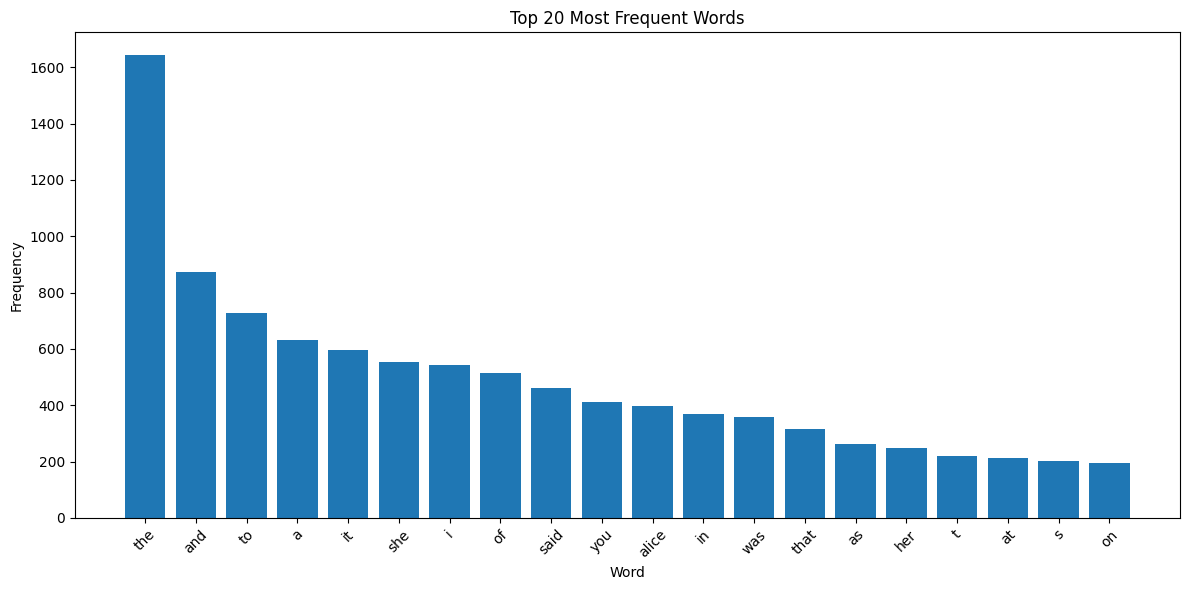

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    frequency_df["Word"],
    frequency_df["Frequency"]
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# STOPWORD REMOVAL

In [ ]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords
filtered_words = [
    word
    for word in clean_words
    if word not in stop_words
]

# Count filtered words
filtered_frequency = Counter(filtered_words)

# Get top 20 meaningful words
top_filtered_words = filtered_frequency.most_common(20)

filtered_frequency_df = pd.DataFrame(
    top_filtered_words,
    columns=["Word", "Frequency"]
)

print("Top 20 Words After Stopword Removal:")
display(filtered_frequency_df)

Top 20 Words After Stopword Removal:


,Word,Frequency
0,said,462
1,alice,398
2,little,128
3,one,104
4,know,88
5,like,85
6,would,83
7,went,83
8,could,77
9,queen,75


# BEFORE vs AFTER STOPWORD REMOVAL

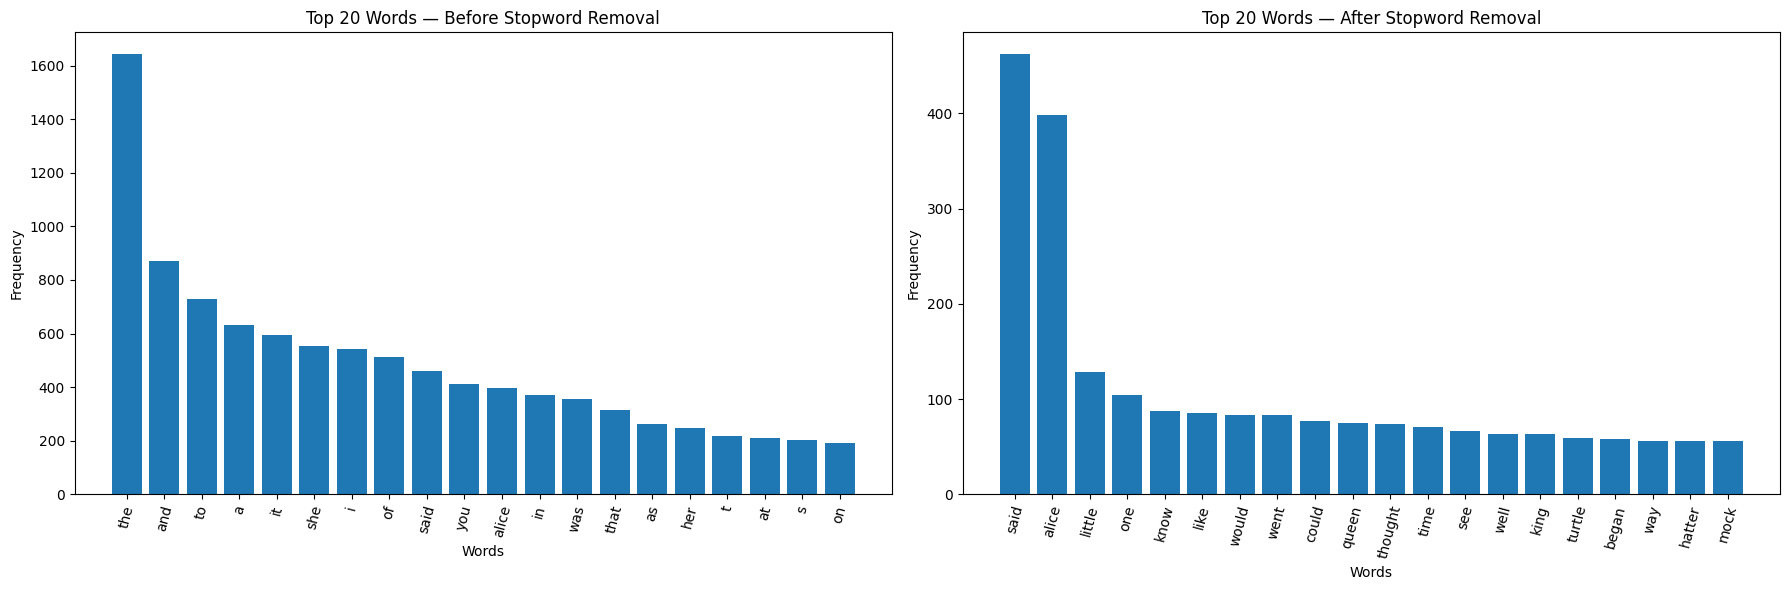

In [ ]:
# Create a NEW figure with two plotting areas.
# This is important because 'axes' must be created before
# we can use axes[0] and axes[1].
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ------------------------------------------------------------
# LEFT PLOT: Top words BEFORE stopword removal
# ------------------------------------------------------------

axes[0].bar(
    frequency_df["Word"],
    frequency_df["Frequency"]
)

axes[0].set_title("Top 20 Words — Before Stopword Removal")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Frequency")

# Rotate word labels so they are easier to read
axes[0].tick_params(axis="x", rotation=75)


# ------------------------------------------------------------
# RIGHT PLOT: Top words AFTER stopword removal
# ------------------------------------------------------------

axes[1].bar(
    filtered_frequency_df["Word"],
    filtered_frequency_df["Frequency"]
)

axes[1].set_title("Top 20 Words — After Stopword Removal")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")

# Rotate word labels for readability
axes[1].tick_params(axis="x", rotation=75)


# Adjust spacing between the two plots
plt.tight_layout()

# Display the comparison
plt.show()

#  WORD CLOUD

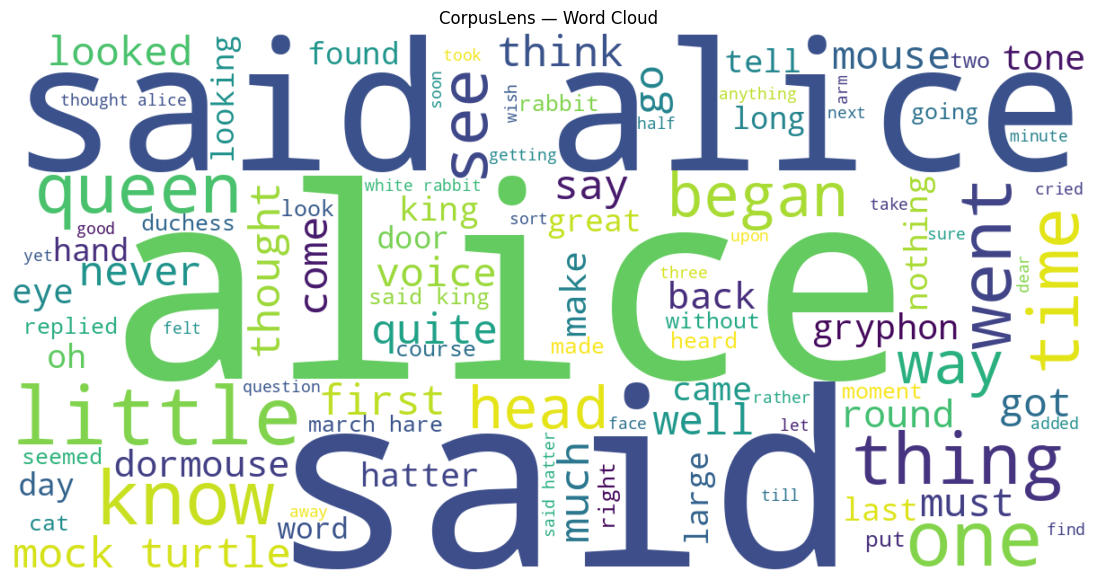

In [ ]:
# Combine filtered words into one text string
filtered_text = " ".join(filtered_words)

# Create word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(filtered_text)

# Display the word cloud
plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("CorpusLens — Word Cloud")

plt.show()

# WORD LENGTH ANALYSIS

Word Length Statistics:
----------------------------------------
Shortest word: 1 characters
Longest word : 14 characters
Average word : 3.94 characters


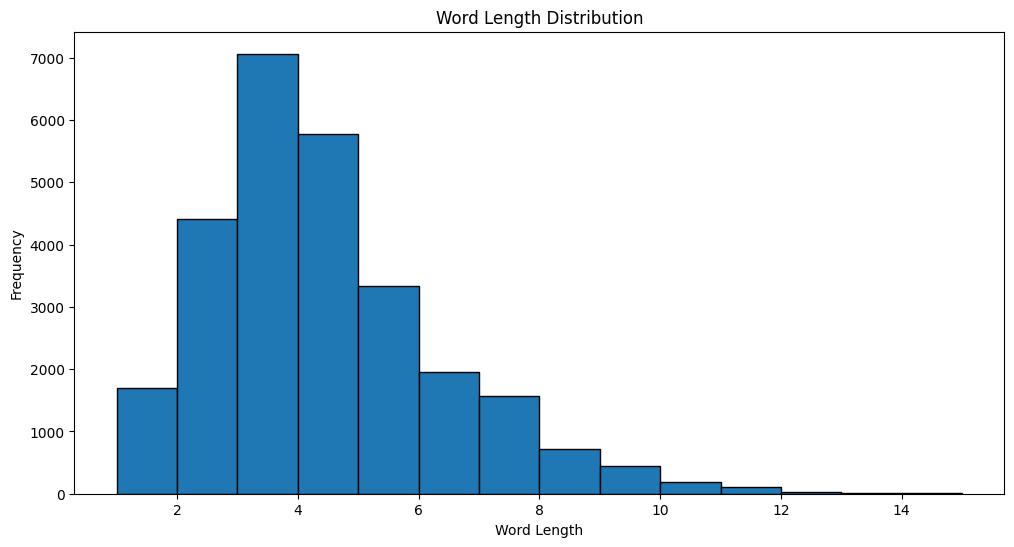

In [ ]:
word_lengths = [
    len(word)
    for word in clean_words
]

# Create DataFrame
word_length_df = pd.DataFrame({
    "Word Length": word_lengths
})

print("Word Length Statistics:")
print("-" * 40)

print(
    f"Shortest word: {min(word_lengths)} characters"
)

print(
    f"Longest word : {max(word_lengths)} characters"
)

print(
    f"Average word : {sum(word_lengths) / len(word_lengths):.2f} characters"
)

# Plot distribution
plt.figure(figsize=(12, 6))

plt.hist(
    word_lengths,
    bins=range(1, max(word_lengths) + 2),
    edgecolor="black"
)

plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

# SENTENCE LENGTH ANALYSIS

Sentence Length Analysis
----------------------------------------
Shortest sentence: 2 words
Longest sentence : 204 words
Average sentence : 20.03 words


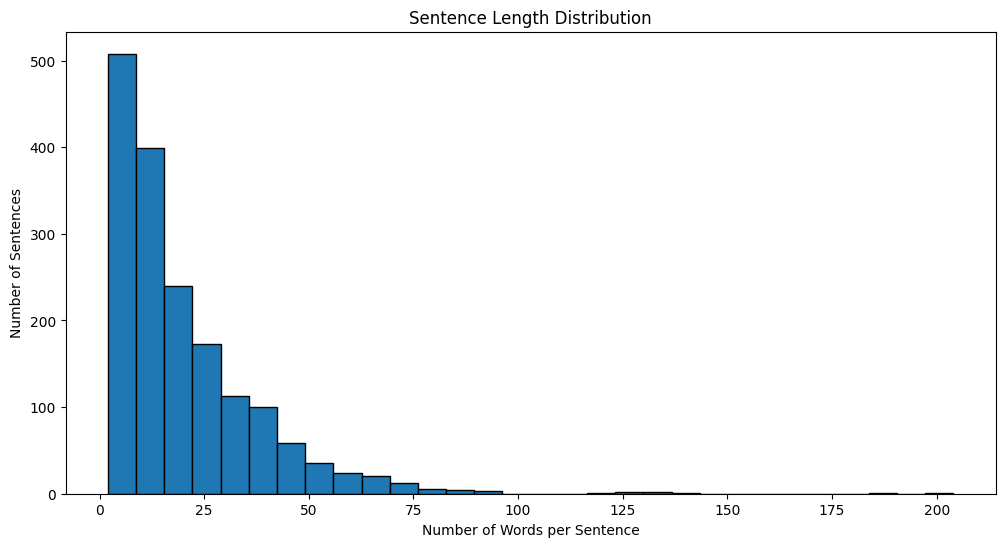

In [ ]:
sentence_lengths = [
    len(sentence)
    for sentence in sentences
]

print("Sentence Length Analysis")
print("-" * 40)

print(
    f"Shortest sentence: {min(sentence_lengths)} words"
)

print(
    f"Longest sentence : {max(sentence_lengths)} words"
)

print(
    f"Average sentence : {sum(sentence_lengths) / len(sentence_lengths):.2f} words"
)

# Plot sentence length distribution
plt.figure(figsize=(12, 6))

plt.hist(
    sentence_lengths,
    bins=30,
    edgecolor="black"
)

plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words per Sentence")
plt.ylabel("Number of Sentences")

plt.show()

# CORPUS HEALTH REPORT

In [ ]:
# Calculate stopword ratio
stopword_count = sum(
    1 for word in clean_words
    if word in stop_words
)

stopword_ratio = stopword_count / total_words

# Percentage of unique words
unique_word_ratio = unique_words / total_words

# Count long sentences
long_sentences = sum(
    1 for length in sentence_lengths
    if length > 30
)

print("=" * 60)
print("                 CORPUS HEALTH REPORT")
print("=" * 60)

print(f"\nTotal words              : {total_words:,}")
print(f"Unique words             : {unique_words:,}")
print(f"Stopword ratio           : {stopword_ratio:.2%}")
print(f"Vocabulary diversity     : {unique_word_ratio:.2%}")
print(f"Sentences > 30 words     : {long_sentences:,}")

print("\nDIAGNOSTICS")
print("-" * 60)

# Check stopword ratio
if stopword_ratio > 0.40:
    print("⚠ High stopword ratio detected.")
    print("  Recommendation: Consider stopword removal.")
else:
    print("✓ Stopword ratio is relatively low.")

# Check lexical diversity
if lexical_diversity > 0.20:
    print("✓ Corpus has relatively rich vocabulary.")
else:
    print("⚠ Vocabulary diversity is relatively low.")

# Check long sentences
if long_sentences > 0:
    print("⚠ Long sentences detected.")
    print("  Recommendation: Consider sentence-level analysis.")
else:
    print("✓ No unusually long sentences detected.")

print("\nCorpus health analysis completed.")

                 CORPUS HEALTH REPORT

Total words              : 27,333
Unique words             : 2,569
Stopword ratio           : 55.22%
Vocabulary diversity     : 9.40%
Sentences > 30 words     : 346

DIAGNOSTICS
------------------------------------------------------------
⚠ High stopword ratio detected.
  Recommendation: Consider stopword removal.
⚠ Vocabulary diversity is relatively low.
⚠ Long sentences detected.
  Recommendation: Consider sentence-level analysis.

Corpus health analysis completed.


#  AUTOMATIC CORPUS INSIGHTS

In [ ]:
print("=" * 60)
print("                 CORPUSLENS INSIGHTS")
print("=" * 60)

# Vocabulary insight
if lexical_diversity >= 0.20:
    print("\n🧠 Vocabulary:")
    print("The corpus shows relatively high lexical diversity.")
else:
    print("\n🧠 Vocabulary:")
    print("The corpus contains a relatively repetitive vocabulary.")

# Sentence complexity
if average_sentence_length > 20:
    print("\n📝 Sentence Structure:")
    print("Sentences are relatively long and may indicate higher "
          "syntactic complexity.")
elif average_sentence_length > 12:
    print("\n📝 Sentence Structure:")
    print("The corpus contains moderately sized sentences.")
else:
    print("\n📝 Sentence Structure:")
    print("The corpus mainly contains short sentences.")

# Word complexity
if average_word_length > 6:
    print("\n🔤 Word Complexity:")
    print("Words tend to be relatively long.")
else:
    print("\n🔤 Word Complexity:")
    print("Words are generally short and simple.")

# Stopword insight
if stopword_ratio > 0.40:
    print("\n🧹 Preprocessing:")
    print("Stopwords represent a significant portion of the corpus.")
    print("Stopword removal may improve downstream NLP analysis.")

print("\n✓ Automatic analysis completed.")

                 CORPUSLENS INSIGHTS

🧠 Vocabulary:
The corpus contains a relatively repetitive vocabulary.

📝 Sentence Structure:
The corpus contains moderately sized sentences.

🔤 Word Complexity:
Words are generally short and simple.

🧹 Preprocessing:
Stopwords represent a significant portion of the corpus.
Stopword removal may improve downstream NLP analysis.

✓ Automatic analysis completed.


#SELECT ANOTHER GUTENBERG DOCUMENT

In [ ]:
print("Available Gutenberg documents:\n")

for i, document in enumerate(gutenberg.fileids(), start=1):
    print(f"{i}. {document}")

# Select document number
choice = int(input("\nEnter document number: "))

selected_document = gutenberg.fileids()[choice - 1]

print("\nSelected document:", selected_document)

# Load selected document
selected_raw_text = gutenberg.raw(selected_document)
selected_words = gutenberg.words(selected_document)
selected_sentences = gutenberg.sents(selected_document)

print("\nDocument successfully loaded!")

print("Characters:", len(selected_raw_text))
print("Words:", len(selected_words))
print("Sentences:", len(selected_sentences))

Available Gutenberg documents:

1. austen-emma.txt
2. austen-persuasion.txt
3. austen-sense.txt
4. bible-kjv.txt
5. blake-poems.txt
6. bryant-stories.txt
7. burgess-busterbrown.txt
8. carroll-alice.txt
9. chesterton-ball.txt
10. chesterton-brown.txt
11. chesterton-thursday.txt
12. edgeworth-parents.txt
13. melville-moby_dick.txt
14. milton-paradise.txt
15. shakespeare-caesar.txt
16. shakespeare-hamlet.txt
17. shakespeare-macbeth.txt
18. whitman-leaves.txt

Enter document number: 14

Selected document: milton-paradise.txt

Document successfully loaded!
Characters: 468220
Words: 96825
Sentences: 1851


# CORPUS COMPARISON

In [ ]:
def analyze_corpus(document_name):
    """
    Analyze a Gutenberg document and return
    important NLP statistics.
    """

    # Load words and sentences
    document_words = gutenberg.words(document_name)
    document_sentences = gutenberg.sents(document_name)

    # Keep alphabetic words only
    cleaned = [
        word.lower()
        for word in document_words
        if word.isalpha()
    ]

    # Calculate statistics
    total = len(cleaned)
    vocabulary_size = len(set(cleaned))

    diversity = vocabulary_size / total

    avg_sentence = (
        total / len(document_sentences)
    )

    return {
        "Document": document_name,
        "Words": total,
        "Unique Words": vocabulary_size,
        "Lexical Diversity": round(diversity, 3),
        "Sentences": len(document_sentences),
        "Avg Sentence Length": round(avg_sentence, 2)
    }


# Select two documents
document_a = "carroll-alice.txt"
document_b = "shakespeare-hamlet.txt"

# Analyze both
analysis_a = analyze_corpus(document_a)
analysis_b = analyze_corpus(document_b)

# Create comparison table
comparison_df = pd.DataFrame([
    analysis_a,
    analysis_b
])

print("CORPUS COMPARISON")
print("=" * 70)

display(comparison_df)

CORPUS COMPARISON


,Document,Words,Unique Words,Lexical Diversity,Sentences,Avg Sentence Length
0,carroll-alice.txt,27333,2569,0.094,1703,16.05
1,shakespeare-hamlet.txt,30266,4699,0.155,3106,9.74


#VISUAL CORPUS COMPARISON

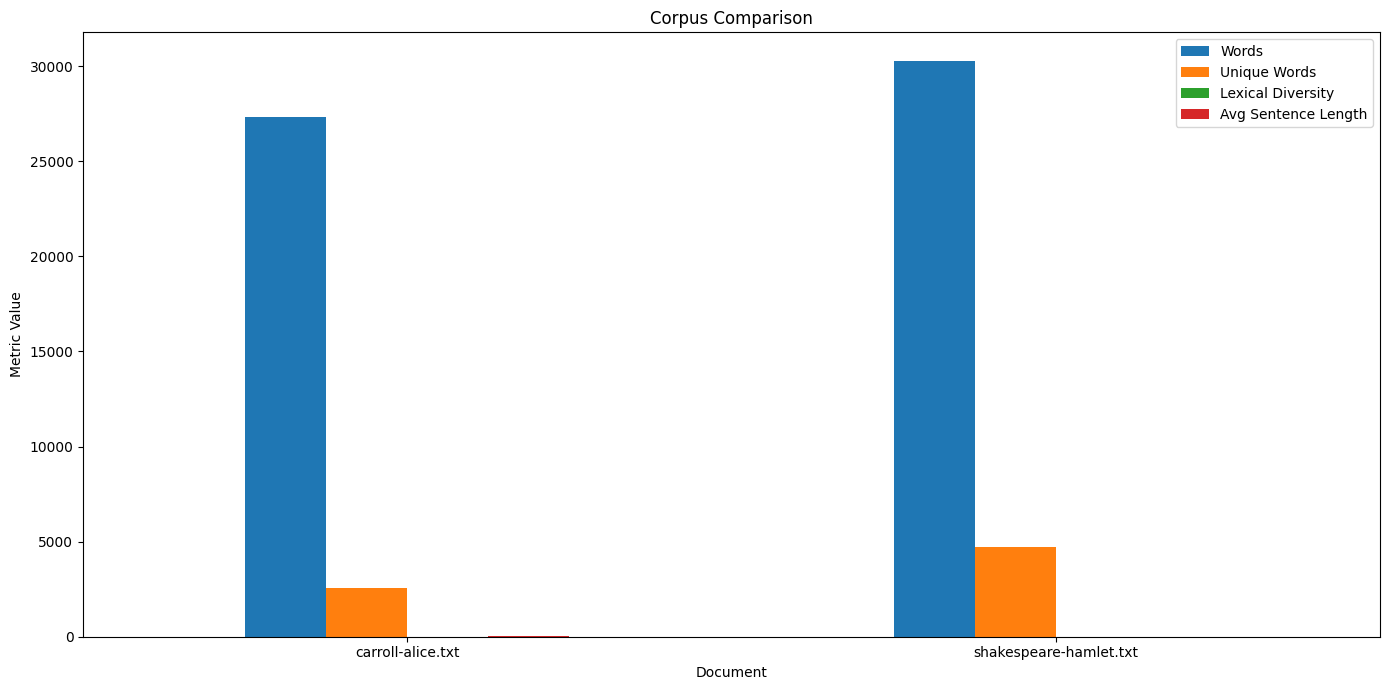

In [ ]:

metrics = [
    "Words",
    "Unique Words",
    "Lexical Diversity",
    "Avg Sentence Length"
]

# Create comparison data
comparison_plot = comparison_df[
    ["Document"] + metrics
].set_index("Document")

# Plot
comparison_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Corpus Comparison")
plt.xlabel("Document")
plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# DISTINCTIVE VOCABULARY

In [ ]:
def get_word_frequency(document_name):
    """
    Return word frequencies for a Gutenberg document.
    """

    words = gutenberg.words(document_name)

    cleaned = [
        word.lower()
        for word in words
        if word.isalpha()
        and word.lower() not in stop_words
    ]

    return Counter(cleaned)


# Get frequencies
freq_a = get_word_frequency(document_a)
freq_b = get_word_frequency(document_b)

# Calculate distinctive words for A
distinctive_a = []

for word, count in freq_a.items():

    other_count = freq_b.get(word, 0)

    score = count - other_count

    distinctive_a.append(
        (word, score)
    )

# Sort by score
distinctive_a.sort(
    key=lambda x: x[1],
    reverse=True
)

print(f"Most distinctive words in {document_a}:")
print("-" * 50)

for word, score in distinctive_a[:20]:
    print(f"{word:20} {score}")

Most distinctive words in carroll-alice.txt:
--------------------------------------------------
said                 449
alice                398
little               115
went                 78
queen                67
thought              60
turtle               59
one                  58
began                58
hatter               56
gryphon              55
mock                 53
rabbit               51
quite                51
think                49
never                48
could                46
voice                46
way                  45
looked               45


# CORPUSLENS FINAL SUMMARY

In [ ]:
print("\n")
print("=" * 65)
print("                 CORPUSLENS ANALYSIS")
print("=" * 65)

print(f"""
Document:
    {document_name}

Corpus Statistics:
    Characters              : {len(raw_text):,}
    Words                   : {total_words:,}
    Unique Words            : {unique_words:,}
    Sentences               : {total_sentences:,}

Linguistic Statistics:
    Average Word Length     : {average_word_length:.2f}
    Average Sentence Length : {average_sentence_length:.2f}
    Lexical Diversity       : {lexical_diversity:.3f}

Preprocessing:
    Stopwords detected      : {stopword_count:,}
    Stopword ratio          : {stopword_ratio:.2%}

Analysis:
    Word frequency analysis : ✓
    Vocabulary analysis     : ✓
    Word-length analysis    : ✓
    Sentence analysis       : ✓
    Word cloud              : ✓
    Corpus health check     : ✓
    Automatic insights      : ✓
    Corpus comparison       : ✓

===============================================================
CorpusLens: From Raw Text → NLP Analysis → Intelligent Insights
===============================================================
""")



                 CORPUSLENS ANALYSIS

Document:
    carroll-alice.txt

Corpus Statistics:
    Characters              : 144,395
    Words                   : 27,333
    Unique Words            : 2,569
    Sentences               : 1,703

Linguistic Statistics:
    Average Word Length     : 3.94
    Average Sentence Length : 16.05
    Lexical Diversity       : 0.094

Preprocessing:
    Stopwords detected      : 15,093
    Stopword ratio          : 55.22%

Analysis:
    Word frequency analysis : ✓
    Vocabulary analysis     : ✓
    Word-length analysis    : ✓
    Sentence analysis       : ✓
    Word cloud              : ✓
    Corpus health check     : ✓
    Automatic insights      : ✓
    Corpus comparison       : ✓

CorpusLens: From Raw Text → NLP Analysis → Intelligent Insights

